/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
3. 著者データの整形中...
✓ 前処理完了: 26358 件
Building graphs for 7 years...

[Graph Info]
  Total Nodes: 107985
  Authors:     81627
  Papers:      26358
  Input Dim:   1024
  Years:       [2020, 2021, 2022, 2023, 2024, 2025, 2026]
Initializing author vectors with paper means...

>>> Training Started...
Epoch 01 | Loss: 54.2989 | MRR: 0.0595 | Consist: 0.962
Epoch 02 | Loss: 37.0505 | MRR: 0.0568 | Consist: 0.985
Epoch 03 | Loss: 33.6530 | MRR: 0.0637 | Consist: 0.987
Epoch 04 | Loss: 33.6266 | MRR: 0.0471 | Consist: 0.991
Epoch 05 | Loss: 33.4135 | MRR: 0.0854 | Consist: 0.993
Epoch 06 | Loss: 33.4590 | MRR: 0.0755 | Consist: 0.992
Epoch 07 | Loss: 33.3449 | MRR: 0.0841 | Consist: 0.993
Epoch 08 | Loss: 34.0111 | MRR: 0.0853 | Consist: 0.993
Epoch 09 | Loss: 33.8350 | MRR: 0.0754 | Consist: 0.995
Epoch 10 | Loss: 33.4924 | MRR: 0.0693 | Consist: 0.995
Epoch 11 | Loss: 34.0676 | MRR: 0.0685 | Consist

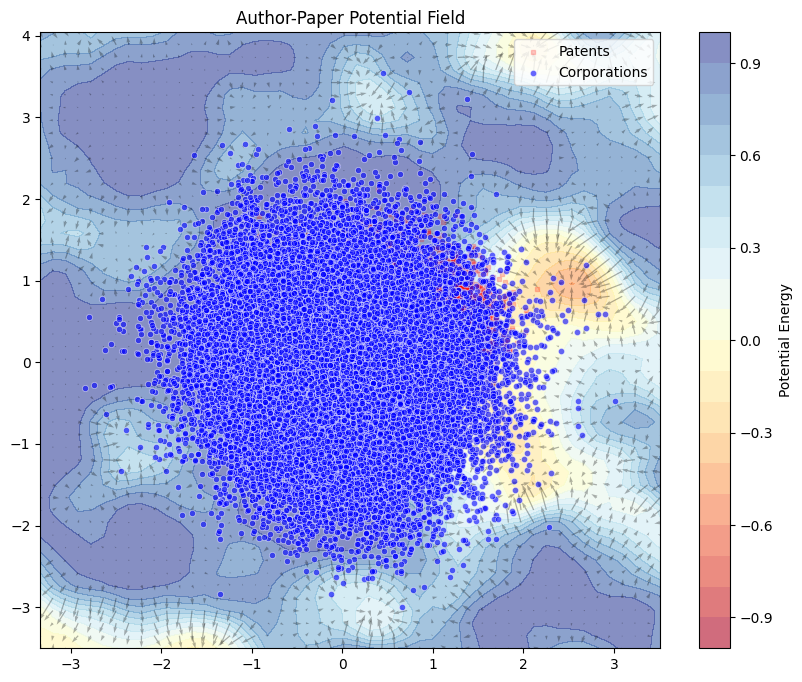

In [2]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            # 改行やカンマの表記揺れに対応してクリーニング
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            # 空白区切りで数値化
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    embeddings = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)

    if not embeddings:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings

    print("3. 著者データの整形中...")
    # 著者名の文字列 "Author A, Author B" をリスト ["Author A", "Author B"] に変換
    def parse_authors(x):
        if isinstance(x, str):
            # カンマで分割し、前後の空白を除去
            return [a.strip() for a in x.split(',')]
        return []

    df['authors_list'] = df['authors'].fillna("").apply(parse_authors)

    # 念のため年でフィルタリング（2020-2026）
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

# === Cell 3: 初期化とグラフ構築関数 ===

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    """
    著者の初期ベクトルを、その人が書いた論文ベクトルの平均で計算する
    """
    print("Initializing author vectors with paper means...")
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts = np.zeros(num_authors, dtype=np.float32)
    
    # Author名 -> Index のマップ
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        
        authors = row['authors_list']
        for a in authors:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx] += 1
    
    # 平均化
    for i in range(num_authors):
        if author_counts[i] > 0:
            author_vectors[i] /= author_counts[i]
        else:
            # 論文データがない著者はランダム初期化
            author_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    """
    著者(Author) - 論文(Paper) のグラフを構築する
    """
    # 全著者と全論文(URLをIDとする)のリスト作成
    all_authors = sorted(list(set([a for auths in df['authors_list'] for a in auths])))
    all_papers = sorted(df['url'].unique().tolist())
    
    # IDマップ作成
    author_to_idx = {auth: i for i, auth in enumerate(all_authors)}
    # 論文IDは、著者の後ろに追加する
    paper_to_idx = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    
    total_nodes = len(all_authors) + len(all_papers)
    
    # 論文の特徴量辞書を作成
    paper_features = {}
    for _, row in df.iterrows():
        paper_features[row['url']] = row['paper_vector']
    
    # 特徴量の次元数を取得
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768

    global_graph_dict = {}
    
    # 'year' カラムでグルーピングして年ごとのグラフを作る
    year_groups = df.groupby('year')
    all_historical_edges = set()
    
    print(f"Building graphs for {len(year_groups)} years...")

    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            url = row['url']
            if url not in paper_to_idx: continue
            p_idx = paper_to_idx[url]
            
            # 著者と論文をつなぐ
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    
                    # 双方向エッジ (Author <-> Paper)
                    edges.append([a_idx, p_idx]) 
                    edges.append([p_idx, a_idx])
                    
                    # 履歴用には Author -> Paper の向きだけ記録
                    all_historical_edges.add((a_idx, p_idx))
        
        if not edges: continue
        
        # ノード特徴行列の初期化 (著者は0, 論文はベクトル)
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: 
                x[p_idx] = torch.tensor(paper_features[url])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        
        # その年に登場したノードのマスク
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        # Dataオブジェクト作成
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0: exit()
    
    if len(df) > 0:
        # 2. グラフ構築
        # corps -> authors, patents -> papers に読み替えて変数を受け取る
        graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
        num_authors = len(authors)
        
        print(f"\n[Graph Info]")
        print(f"  Total Nodes: {total_n}")
        print(f"  Authors:     {num_authors}")
        print(f"  Papers:      {len(papers)}")
        print(f"  Input Dim:   {in_dim}")
        print(f"  Years:       {list(graphs.keys())}")

        # 3. 著者の初期ベクトル計算
        init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

        # 4. モデル初期化
        # UnifiedVGAEの num_corps 引数には num_authors を渡す
        model = UnifiedVGAE(
            num_nodes=total_n, 
            num_corps=num_authors, 
            input_dim=in_dim,
            hidden_dim=128, 
            latent_dim=2, 
            initial_corp_vectors=init_vectors
        ).to(device)

        # 5. 学習開始
        print("\n>>> Training Started...")
        model, best_mrr, history = train_model_improved(
            model, graphs, num_authors, hist_edges, num_epochs=15
        )
        
        print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")

        # 6. 可視化 (2Dポテンシャル場)
        # 凡例を Author / Paper に変えるため、可視化関数を少し調整して呼び出すか
        # 既存の visualize_potential_landscape_2d をそのまま使っても動作します
        last_year = max(graphs.keys())
        print(f"\n[Visualization] Year: {last_year}")
        
        # 可視化実行
        visualize_potential_landscape_2d(model, graphs[last_year], num_authors, device, title="Author-Paper Potential Field")
    else:
        print("データ不足のため終了します。")

Nature-style Benchmarking (Static vs VGRNN vs GODE vs P-NODE)

>>> Starting Multi-run Training...
Starting comparison with 5 runs (Including Static)...

--- Run 1/5 ---
  [Static] Run 1 Time:  7.16s | Final AUC: 0.5526 | MRR: 0.0547
  [VGRNN] Run 1 Time:  19.28s | Final AUC: 0.5141 | MRR: 0.0262
  [StandardGODE] Run 1 Time:  9.20s | Final AUC: 0.4145 | MRR: 0.0184
  [P-NODE] Run 1 Time:  9.79s | Final AUC: 0.4502 | MRR: 0.0240

--- Run 2/5 ---
  [Static] Run 2 Time:  7.21s | Final AUC: 0.5424 | MRR: 0.0627
  [VGRNN] Run 2 Time:  19.46s | Final AUC: 0.4754 | MRR: 0.0207
  [StandardGODE] Run 2 Time:  9.24s | Final AUC: 0.4673 | MRR: 0.0246
  [P-NODE] Run 2 Time:  9.81s | Final AUC: 0.3997 | MRR: 0.0183

--- Run 3/5 ---
  [Static] Run 3 Time:  7.21s | Final AUC: 0.5160 | MRR: 0.0683
  [VGRNN] Run 3 Time:  19.51s | Final AUC: 0.5005 | MRR: 0.0241
  [StandardGODE] Run 3 Time:  9.23s | Final AUC: 0.4039 | MRR: 0.0186
  [P-NODE] Run 3 Time:  9.81s | Final AUC: 0.4225 | MRR: 0.0218

--- Run 4/

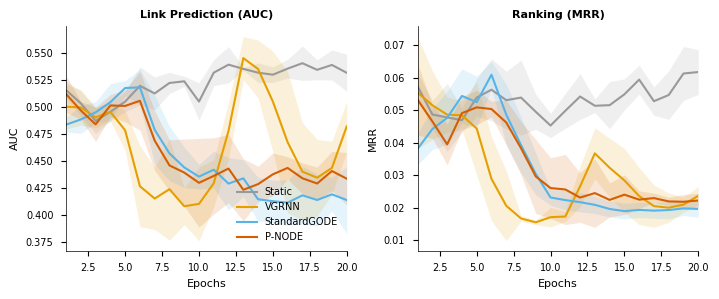

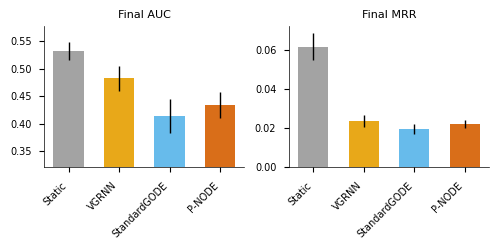

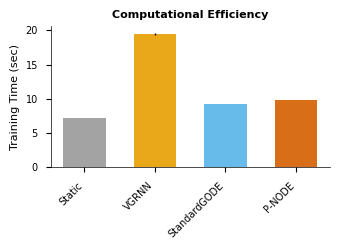


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Significance Test Results:
  Metric              Comparison   p-value Significance
0    auc        P-NODE vs Static  2.62e-04          ***
1    auc         P-NODE vs VGRNN  1.99e-02            *
2    auc  P-NODE vs StandardGODE  3.47e-01           ns
3    mrr        P-NODE vs Static  1.41e-04          ***
4    mrr         P-NODE vs VGRNN  4.49e-01           ns
5    mrr  P-NODE vs StandardGODE  1.68e-01           ns


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns
import time

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """Nature投稿用のプロットスタイル設定"""
    plt.style.use('seaborn-v0_8-paper')
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 2.5), # 89mm幅 (Single Column)
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

# カラーパレット (Static入りの構成)
NATURE_COLORS = {
    "Static": "#999999",       # グレー (Baseline)
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"        # バーミリオン (提案手法・強調)
}

# ============================================================
# 1. 複数試行対応の学習関数 (Static対応版)
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    Staticを含む4手法で比較実験を行う関数
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    all_histories = {name: [] for name in models.keys()}
    training_times = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs (Including Static)...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            start_time = time.time()

            # --- Training Loop ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Reconstruction Loss
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Prediction Loss (Static以外)
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential Loss (P-NODEのみ)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            end_time = time.time()
            elapsed_time = end_time - start_time
            training_times[name].append(elapsed_time)

            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            print(f"  [{name}] Run {run+1} Time: {elapsed_time: .2f}s | Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 2. 統計的有意差検定
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        proposed_vals = final_scores[proposed_name][metric]
        for name in final_scores.keys():
            if name == proposed_name: continue
            
            target_vals = final_scores[name][metric]
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': f"{p_val:.2e}",
                'Significance': sig
            })
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Functions
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # Double Column Width
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for name, runs in all_histories.items():
            matrix = np.array([h[metric] for h in runs])
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        if i == 0: ax.legend(frameon=False, loc='lower right')
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300)
    plt.show()

def plot_significance_bars(final_scores):
    set_nature_style()
    metrics = ['auc', 'mrr']
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, 
               ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        min_val = min(means) - max(stds)*3
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

def plot_time_comparison(training_times):
    set_nature_style()
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    names = list(training_times.keys())
    means = [np.mean(training_times[n]) for n in names]
    stds = [np.std(training_times[n]) for n in names]
    
    x_pos = np.arange(len(names))
    colors = [NATURE_COLORS[n] for n in names]
    
    bars = ax.bar(x_pos, means, yerr=stds, align='center', 
                  alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title('Computational Efficiency', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./outputs/nature_training_time.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if not os.path.exists('./outputs'): os.makedirs('./outputs')
    print("=" * 60)
    print("Nature-style Benchmarking (Static vs VGRNN vs GODE vs P-NODE)")
    print("=" * 60)

    # 1. Config構築 (前段のコードで graphs 等が生成されている前提)
    # もし変数が消えている場合は前段の `build_author_paper_graphs` を再実行してください
    if 'graphs' in locals():
        config = {
            'graphs': graphs,
            'total_n': total_n,
            'num_corps': num_authors,
            'in_dim': in_dim
        }
        
        # 2. 実験実行
        print("\n>>> Starting Multi-run Training...")
        final_scores, all_histories, training_times = train_multiple_runs(
            config, 
            num_runs=5,     # 論文用なら5~10回推奨
            num_epochs=20, 
            latent_dim=16, 
            hidden_dim=128
        )
        
        # 3. プロット生成
        print("\n>>> Generating Nature-style Plots...")
        plot_nature_comparison(all_histories)
        plot_significance_bars(final_scores)
        plot_time_comparison(training_times)
        
        # 4. 統計検定結果
        df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
        print("\nSignificance Test Results:")
        print(df_sig)
        
    else:
        print("エラー: グラフデータが見つかりません。")
        print("前段の `build_author_paper_graphs` を実行して `graphs` 変数を生成してください。")

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
3. 著者データの整形中...
✓ 前処理完了: 26358 件

[Filtering] 論文を 5 本以上書いている著者を抽出中...
  Total Authors: 81627 -> Active Authors: 3620
  (削減率: 95.6%)
  Valid Papers: 26358 -> 13825 (著者が残った論文のみ)
Building graphs for 7 years...

[Graph Info]
  Total Nodes: 17445
  Authors:     3620
  Papers:      13825
  Input Dim:   1024
  Years:       [2020, 2021, 2022, 2023, 2024, 2025, 2026]
Initializing author vectors with paper means...

>>> Training Started...
Epoch 01 | Loss: 45.0787 | MRR: 0.0620 | Consist: 0.971
Epoch 02 | Loss: 38.9479 | MRR: 0.0527 | Consist: 0.986
Epoch 03 | Loss: 37.3540 | MRR: 0.0631 | Consist: 0.989
Epoch 04 | Loss: 35.3903 | MRR: 0.0694 | Consist: 0.992
Epoch 05 | Loss: 35.7075 | MRR: 0.0686 | Consist: 0.992
Epoch 06 | Loss: 35.2594 | MRR: 0.0658 | Consist: 0.992
Epoch 07 | Loss: 35.3267 | MRR: 0.0671 | Consist: 0.992
Epoch 08 | Loss: 35.0885 | MRR: 0.0607 | Consist: 0.994
Epoch 09 | Loss: 34

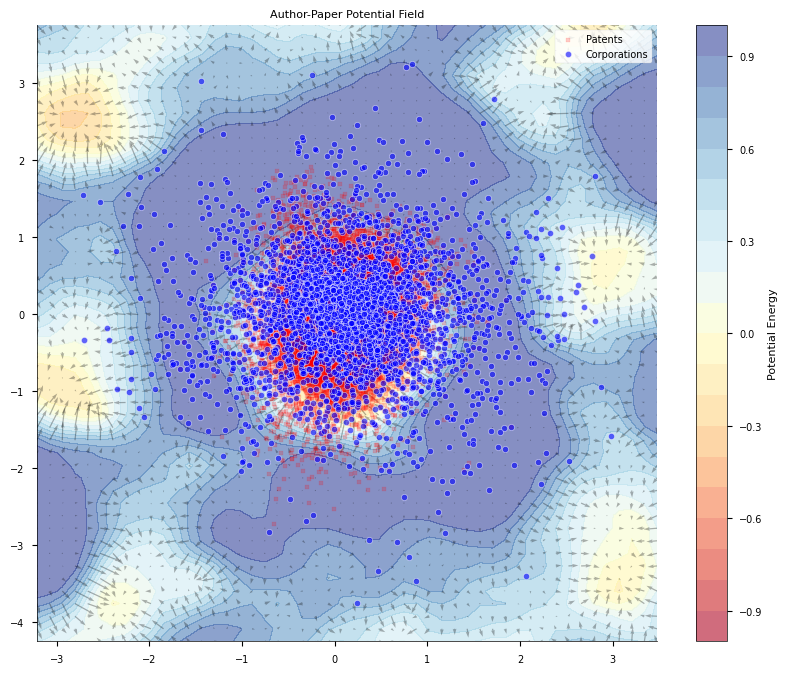

In [4]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            # 改行やカンマの表記揺れに対応してクリーニング
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            # 空白区切りで数値化
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    embeddings = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)

    if not embeddings:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings

    print("3. 著者データの整形中...")
    # 著者名の文字列 "Author A, Author B" をリスト ["Author A", "Author B"] に変換
    def parse_authors(x):
        if isinstance(x, str):
            # カンマで分割し、前後の空白を除去
            return [a.strip() for a in x.split(',')]
        return []

    df['authors_list'] = df['authors'].fillna("").apply(parse_authors)

    # 念のため年でフィルタリング（2020-2026）
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def filter_active_authors(df, min_papers=5):
    """
    指定した本数以上の論文を書いている著者のみを残すフィルタリング関数
    """
    print(f"\n[Filtering] 論文を {min_papers} 本以上書いている著者を抽出中...")
    
    # 1. 全著者の出現回数をカウント
    all_authors_flat = [a for sublist in df['authors_list'] for a in sublist]
    author_counts = Counter(all_authors_flat)
    
    total_authors = len(author_counts)
    
    # 2. 条件を満たす著者セットを作成
    active_authors = {a for a, c in author_counts.items() if c >= min_papers}
    
    print(f"  Total Authors: {total_authors} -> Active Authors: {len(active_authors)}")
    print(f"  (削減率: {100 * (1 - len(active_authors)/total_authors):.1f}%)")
    
    # 3. DataFrame内の著者リストを更新（アクティブな著者だけ残す）
    def filter_row(auth_list):
        return [a for a in auth_list if a in active_authors]
    
    df['authors_list'] = df['authors_list'].apply(filter_row)
    
    # 4. 著者が0人になってしまった論文（マイナーな著者しかいない論文）を除外するか？
    # トレンド分析なら「主要な著者が関わっていない論文」は除外してOK
    original_len = len(df)
    df = df[df['authors_list'].map(len) > 0].copy()
    
    print(f"  Valid Papers: {original_len} -> {len(df)} (著者が残った論文のみ)")
    
    return df

# === Cell 3: 初期化とグラフ構築関数 ===

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    """
    著者の初期ベクトルを、その人が書いた論文ベクトルの平均で計算する
    """
    print("Initializing author vectors with paper means...")
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts = np.zeros(num_authors, dtype=np.float32)
    
    # Author名 -> Index のマップ
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        
        authors = row['authors_list']
        for a in authors:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx] += 1
    
    # 平均化
    for i in range(num_authors):
        if author_counts[i] > 0:
            author_vectors[i] /= author_counts[i]
        else:
            # 論文データがない著者はランダム初期化
            author_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    """
    著者(Author) - 論文(Paper) のグラフを構築する
    """
    # 全著者と全論文(URLをIDとする)のリスト作成
    all_authors = sorted(list(set([a for auths in df['authors_list'] for a in auths])))
    all_papers = sorted(df['url'].unique().tolist())
    
    # IDマップ作成
    author_to_idx = {auth: i for i, auth in enumerate(all_authors)}
    # 論文IDは、著者の後ろに追加する
    paper_to_idx = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    
    total_nodes = len(all_authors) + len(all_papers)
    
    # 論文の特徴量辞書を作成
    paper_features = {}
    for _, row in df.iterrows():
        paper_features[row['url']] = row['paper_vector']
    
    # 特徴量の次元数を取得
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768

    global_graph_dict = {}
    
    # 'year' カラムでグルーピングして年ごとのグラフを作る
    year_groups = df.groupby('year')
    all_historical_edges = set()
    
    print(f"Building graphs for {len(year_groups)} years...")

    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            url = row['url']
            if url not in paper_to_idx: continue
            p_idx = paper_to_idx[url]
            
            # 著者と論文をつなぐ
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    
                    # 双方向エッジ (Author <-> Paper)
                    edges.append([a_idx, p_idx]) 
                    edges.append([p_idx, a_idx])
                    
                    # 履歴用には Author -> Paper の向きだけ記録
                    all_historical_edges.add((a_idx, p_idx))
        
        if not edges: continue
        
        # ノード特徴行列の初期化 (著者は0, 論文はベクトル)
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: 
                x[p_idx] = torch.tensor(paper_features[url])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        
        # その年に登場したノードのマスク
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        # Dataオブジェクト作成
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0: exit()

    # 5本以上論文を書いている著者のみに絞る
    df = filter_active_authors(df, min_papers=5)
    
    if len(df) > 0:
        # 2. グラフ構築
        # corps -> authors, patents -> papers に読み替えて変数を受け取る
        graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
        num_authors = len(authors)
        
        print(f"\n[Graph Info]")
        print(f"  Total Nodes: {total_n}")
        print(f"  Authors:     {num_authors}")
        print(f"  Papers:      {len(papers)}")
        print(f"  Input Dim:   {in_dim}")
        print(f"  Years:       {list(graphs.keys())}")

        # 3. 著者の初期ベクトル計算
        init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

        # 4. モデル初期化
        # UnifiedVGAEの num_corps 引数には num_authors を渡す
        model = UnifiedVGAE(
            num_nodes=total_n, 
            num_corps=num_authors, 
            input_dim=in_dim,
            hidden_dim=128, 
            latent_dim=2, 
            initial_corp_vectors=init_vectors
        ).to(device)

        # 5. 学習開始
        print("\n>>> Training Started...")
        model, best_mrr, history = train_model_improved(
            model, graphs, num_authors, hist_edges, num_epochs=15
        )
        
        print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")

        # 6. 可視化 (2Dポテンシャル場)
        # 凡例を Author / Paper に変えるため、可視化関数を少し調整して呼び出すか
        # 既存の visualize_potential_landscape_2d をそのまま使っても動作します
        last_year = max(graphs.keys())
        print(f"\n[Visualization] Year: {last_year}")
        
        # 可視化実行
        visualize_potential_landscape_2d(model, graphs[last_year], num_authors, device, title="Author-Paper Potential Field")
    else:
        print("データ不足のため終了します。")

Nature-style Benchmarking (Static vs VGRNN vs GODE vs P-NODE)

>>> Starting Multi-run Training...
Starting comparison with 10 runs (Including Static)...

--- Run 1/10 ---
  [Static] Run 1 Time:  1.78s | Final AUC: 0.4713 | MRR: 0.0295
  [VGRNN] Run 1 Time:  3.71s | Final AUC: 0.4781 | MRR: 0.0225
  [StandardGODE] Run 1 Time:  2.21s | Final AUC: 0.5069 | MRR: 0.0319
  [P-NODE] Run 1 Time:  2.39s | Final AUC: 0.4824 | MRR: 0.0283

--- Run 2/10 ---
  [Static] Run 2 Time:  1.77s | Final AUC: 0.5405 | MRR: 0.0323
  [VGRNN] Run 2 Time:  3.72s | Final AUC: 0.4735 | MRR: 0.0238
  [StandardGODE] Run 2 Time:  2.22s | Final AUC: 0.4961 | MRR: 0.0297
  [P-NODE] Run 2 Time:  2.40s | Final AUC: 0.4866 | MRR: 0.0267

--- Run 3/10 ---
  [Static] Run 3 Time:  1.78s | Final AUC: 0.4506 | MRR: 0.0277
  [VGRNN] Run 3 Time:  3.72s | Final AUC: 0.4680 | MRR: 0.0230
  [StandardGODE] Run 3 Time:  2.21s | Final AUC: 0.4980 | MRR: 0.0298
  [P-NODE] Run 3 Time:  2.40s | Final AUC: 0.4752 | MRR: 0.0285

--- Run 4

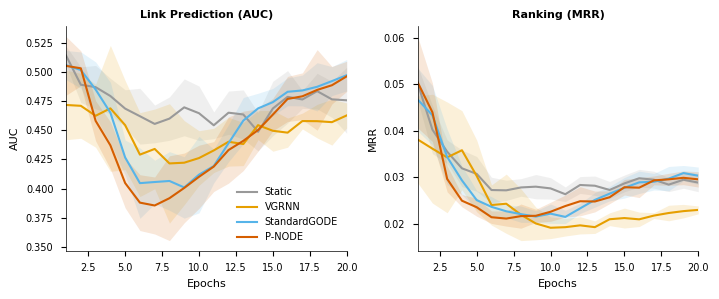

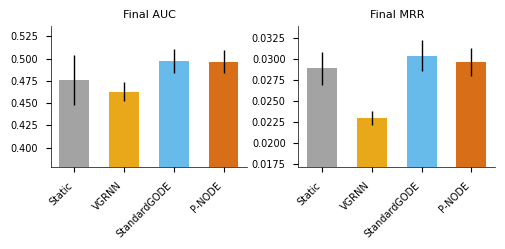

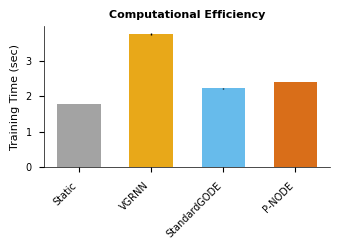


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Significance Test Results:
  Metric              Comparison   p-value Significance
0    auc        P-NODE vs Static  7.00e-02           ns
1    auc         P-NODE vs VGRNN  1.33e-05          ***
2    auc  P-NODE vs StandardGODE  8.80e-01           ns
3    mrr        P-NODE vs Static  4.24e-01           ns
4    mrr         P-NODE vs VGRNN  6.79e-08          ***
5    mrr  P-NODE vs StandardGODE  3.58e-01           ns


In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns
import time

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """Nature投稿用のプロットスタイル設定"""
    plt.style.use('seaborn-v0_8-paper')
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 2.5), # 89mm幅 (Single Column)
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

# カラーパレット (Static入りの構成)
NATURE_COLORS = {
    "Static": "#999999",       # グレー (Baseline)
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"        # バーミリオン (提案手法・強調)
}

# ============================================================
# 1. 複数試行対応の学習関数 (Static対応版)
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    Staticを含む4手法で比較実験を行う関数
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    all_histories = {name: [] for name in models.keys()}
    training_times = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs (Including Static)...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            start_time = time.time()

            # --- Training Loop ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Reconstruction Loss
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Prediction Loss (Static以外)
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential Loss (P-NODEのみ)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            end_time = time.time()
            elapsed_time = end_time - start_time
            training_times[name].append(elapsed_time)

            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            print(f"  [{name}] Run {run+1} Time: {elapsed_time: .2f}s | Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 2. 統計的有意差検定
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        proposed_vals = final_scores[proposed_name][metric]
        for name in final_scores.keys():
            if name == proposed_name: continue
            
            target_vals = final_scores[name][metric]
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': f"{p_val:.2e}",
                'Significance': sig
            })
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Functions
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # Double Column Width
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for name, runs in all_histories.items():
            matrix = np.array([h[metric] for h in runs])
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        if i == 0: ax.legend(frameon=False, loc='lower right')
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300)
    plt.show()

def plot_significance_bars(final_scores):
    set_nature_style()
    metrics = ['auc', 'mrr']
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, 
               ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        min_val = min(means) - max(stds)*3
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

def plot_time_comparison(training_times):
    set_nature_style()
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    names = list(training_times.keys())
    means = [np.mean(training_times[n]) for n in names]
    stds = [np.std(training_times[n]) for n in names]
    
    x_pos = np.arange(len(names))
    colors = [NATURE_COLORS[n] for n in names]
    
    bars = ax.bar(x_pos, means, yerr=stds, align='center', 
                  alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title('Computational Efficiency', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./outputs/nature_training_time.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if not os.path.exists('./outputs'): os.makedirs('./outputs')
    print("=" * 60)
    print("Nature-style Benchmarking (Static vs VGRNN vs GODE vs P-NODE)")
    print("=" * 60)

    # 1. Config構築 (前段のコードで graphs 等が生成されている前提)
    # もし変数が消えている場合は前段の `build_author_paper_graphs` を再実行してください
    if 'graphs' in locals():
        config = {
            'graphs': graphs,
            'total_n': total_n,
            'num_corps': num_authors,
            'in_dim': in_dim
        }
        
        # 2. 実験実行
        print("\n>>> Starting Multi-run Training...")
        final_scores, all_histories, training_times = train_multiple_runs(
            config, 
            num_runs=10,     # 論文用なら5~10回推奨
            num_epochs=20, 
            latent_dim=16, 
            hidden_dim=128
        )
        
        # 3. プロット生成
        print("\n>>> Generating Nature-style Plots...")
        plot_nature_comparison(all_histories)
        plot_significance_bars(final_scores)
        plot_time_comparison(training_times)
        
        # 4. 統計検定結果
        df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
        print("\nSignificance Test Results:")
        print(df_sig)
        
    else:
        print("エラー: グラフデータが見つかりません。")
        print("前段の `build_author_paper_graphs` を実行して `graphs` 変数を生成してください。")

Visualizing Year: 2026


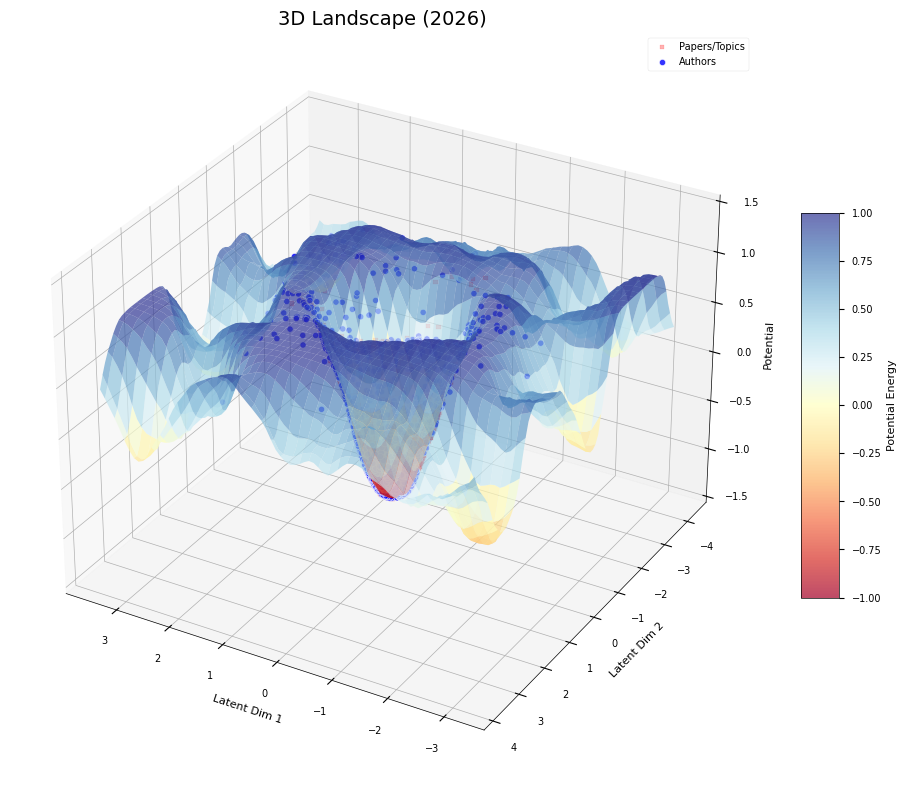

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

# ============================================================
# 3D可視化関数の定義 (このセルで再定義しておくと確実です)
# ============================================================
def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    model.eval()
    data = data.to(device)
    
    # 1. 潜在変数の取得
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. 表示範囲の決定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 3. グリッドデータの作成 (高解像度)
    # モデル内の potential_net を使って地形を計算
    if hasattr(model, 'temporal_predictor'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    X, Y, Z = pot_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 4. プロット
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 地形 (Surface)
    # cmap='RdYlBu' : 青が低い(安定)、赤が高い(不安定)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0, 
                           edgecolor='none', alpha=0.7)
    
    # カラーバー
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Potential Energy')

    # 5. ノードのプロット (高さはポテンシャル値に合わせる)
    with torch.no_grad():
        potentials_nodes = pot_net(z).cpu().numpy().flatten()
    
    # 論文/特許 (Paper/Patent) -> 赤い四角
    # num_corps (num_authors) 以降のインデックス
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    
    # 数が多い場合はサンプリング (描画負荷軽減)
    if len(z_p) > 1000:
        idx = np.random.choice(len(z_p), 1000, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, 
               alpha=0.3, label='Papers/Topics', depthshade=True)

    # 著者/企業 (Author/Corp) -> 青い丸
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    
    if len(z_c) > 1000:
        idx = np.random.choice(len(z_c), 1000, replace=False)
        z_c = z_c[idx]
        pot_c = pot_c[idx]

    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, 
               edgecolors='white', linewidth=0.5, alpha=0.8, 
               label='Authors', depthshade=True)

    # ラベルと視点
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    ax.set_zlim(-1.5, 1.5) # Z軸の範囲固定
    
    # 視点変更 (仰角30度, 方位角120度)
    ax.view_init(elev=30, azim=120)
    plt.legend()
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
# 直前の学習セルで作成された変数が存在するか確認してから実行
if 'model' in locals() and 'graphs' in locals():
    # 最後の年を取得
    target_year = max(graphs.keys())
    print(f"Visualizing Year: {target_year}")
    
    # num_authors変数がなければ num_corps を使う（変数名の互換性）
    n_authors = num_authors if 'num_authors' in locals() else config['num_corps']
    
    visualize_potential_landscape_3d(
        model, 
        graphs[target_year], 
        n_authors, 
        device, 
        title=f"3D Landscape ({target_year})"
    )
else:
    print("エラー: 学習済みモデル 'model' やグラフデータ 'graphs' が見つかりません。")
    print("先に学習を実行してください。")


[Evaluation] Verifying Attractor Validity (Potential vs Density)...
Evaluation plot saved to ./outputs/
Correlation: -0.8223 (Expected: Negative)


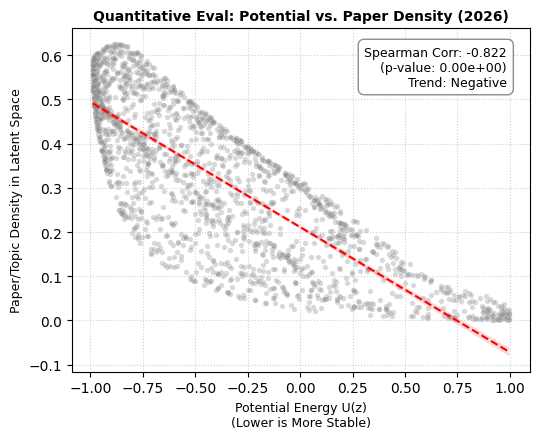

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_quantitative_correlation(model, config, num_authors, device, year_idx=-1):
    # スタイル設定（英語論文仕様）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (Potential vs Density)...")
    
    # 1. データ準備 (指定された年のグラフを取得)
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    # 2. 潜在変数とポテンシャル値の計算
    with torch.no_grad():
        # 次元の不整合があれば補正
        if hasattr(model, 'corp_embeddings'):
            expected_dim = model.corp_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 3. 論文(Paper)ノードの抽出
    # num_authors 以降が Paper/Topic ノード
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # データが少なすぎる場合のガード
    if len(paper_z) < 10:
        print("Not enough paper nodes for density estimation.")
        return

    # 4. 密度推定 (KDE)
    # 高次元だと計算できないためPCAで2次元に落としてから密度を計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        # 転置して (2, N) の形にする
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"KDE Error: {e}")
        return

    # 5. 相関計算 (Spearman)
    # 理論通りなら「負の相関」になるはず（ポテンシャルが低いほど密度が高い）
    corr, p_value = spearmanr(paper_potentials, densities)
    
    # 6. プロット
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    # 描画負荷軽減のためのサンプリング
    if len(paper_potentials) > 2000:
        idx = np.random.choice(len(paper_potentials), 2000, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = paper_potentials
        plot_y = densities
        alpha_val = 0.5
        
    # 散布図
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', 
               edgecolors='white', linewidth=0.3, label='Papers/Topics')
    
    # 回帰直線 (トレンドライン)
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # ラベル設定
    ax.set_title(f"Quantitative Eval: Potential vs. Paper Density ({target_year})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Paper/Topic Density in Latent Space", fontsize=9)
    
    # 統計量テキスト表示
    correlation_text = "Negative" if corr < 0 else "Positive"
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n"
                  f"Trend: {correlation_text}")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/quantitative_eval_arxiv.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/quantitative_eval_arxiv.png', dpi=300)

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f} (Expected: Negative)")
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    if 'model' in locals() and 'config' in locals():
        # 変数名の互換性チェック
        n_authors = config['num_corps'] if 'num_corps' in config else num_authors
        
        evaluate_quantitative_correlation(
            model, 
            config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("エラー: 学習済みモデルが見つかりません。")


[Evaluation] 技術戦略マップ（定義修正版）を作成中...
修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png


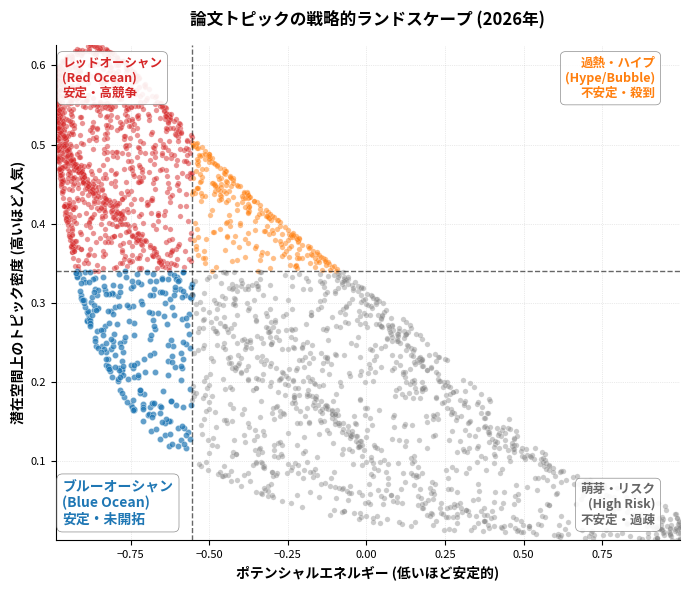

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (定義修正版)
# ============================================================
def evaluate_strategic_quadrants_jp_corrected(model, config, num_authors, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（定義修正版）を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        if hasattr(model, 'corp_embeddings'):
            expected_dim = model.corp_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文(Paper/Topic)データのみ抽出
    # num_authors 以降のインデックス
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # --- 2. 密度推定 (KDE) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # サンプリング
    N_PLOT = 3000
    if len(paper_potentials) > N_PLOT:
        idx = np.random.choice(len(paper_potentials), N_PLOT, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = paper_potentials
        plot_y = densities

    # --- 3. 4象限の分類ロジック (修正版) ---
    x_thr = np.median(plot_x) # ポテンシャル中央値
    y_thr = np.median(plot_y) # 密度中央値
    
    # 【左下】ブルーオーシャン (安定 & 低密度) -> 最有望・狙い目
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 【左上】レッドオーシャン (安定 & 高密度) -> 既存・飽和・激戦区
    mask_red = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 【右上】過熱・ハイプ (不安定 & 高密度) -> バブル・流行・一時的
    mask_hype = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 【右下】萌芽・リスク (不安定 & 低密度) -> 探索・黎明期
    mask_risk = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 左上: レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (飽和)', edgecolors='white', linewidth=0.2)
    
    # 左下: ブルーオーシャン (青 - 最も目立たせる)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=20, alpha=0.7, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.3)
    
    # 右上: 過熱・ハイプ (オレンジ/黄色)
    ax.scatter(plot_x[mask_hype], plot_y[mask_hype], c='#ff7f0e', s=15, alpha=0.5, 
               label='過熱・ハイプ (バブル)', edgecolors='white', linewidth=0.2)
    
    # 右下: 萌芽・リスク (灰)
    ax.scatter(plot_x[mask_risk], plot_y[mask_risk], c='#7f7f7f', s=15, alpha=0.4, 
               label='萌芽・リスク (探索)', edgecolors='white', linewidth=0.2)

    # しきい値線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # ラベル配置 (ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5)
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上
    ax.text(x_min + (x_thr - x_min)*0.05, y_max - (y_max - y_thr)*0.05, 
            "レッドオーシャン\n(Red Ocean)\n安定・高競争", 
            fontsize=9, color='#d62728', fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下 (ここがターゲット)
    ax.text(x_min + (x_thr - x_min)*0.05, y_min + (y_thr - y_min)*0.05, 
            "ブルーオーシャン\n(Blue Ocean)\n安定・未開拓", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上
    ax.text(x_max - (x_max - x_thr)*0.05, y_max - (y_max - y_thr)*0.05, 
            "過熱・ハイプ\n(Hype/Bubble)\n不安定・殺到", 
            fontsize=9, color='#ff7f0e', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下
    ax.text(x_max - (x_max - x_thr)*0.05, y_min + (y_thr - y_min)*0.05, 
            "萌芽・リスク\n(High Risk)\n不安定・過疎", 
            fontsize=9, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上のトピック密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"論文トピックの戦略的ランドスケープ ({target_year}年)", fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.png', dpi=300)
    
    print("修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        # 変数名の互換性チェック
        n_authors = config['num_corps'] if 'num_corps' in config else num_authors
        
        evaluate_strategic_quadrants_jp_corrected(
            model, config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("Model or config not loaded.")

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_quadrant_papers(model, config, df, num_authors, device, year_idx=-1):
    print(f"\n[Analysis] 各象限の代表的な論文を抽出しています...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ネットワーク取得
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net

    with torch.no_grad():
        # 次元調整とエンコード
        if hasattr(model, 'corp_embeddings'):
            expected_dim = model.corp_embeddings.embedding_dim
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- 2. 論文データの抽出 ---
    # ノードIDのうち、num_authors 以降が論文ノード
    paper_indices_in_graph = np.arange(num_authors, len(z_np))
    paper_z = z_np[paper_indices_in_graph]
    paper_pots = potentials[paper_indices_in_graph]
    
    # 密度計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        paper_densities = kde(z_2d.T)
    except:
        print("密度計算に失敗しました（データ点不足）。")
        return pd.DataFrame()

    # --- 3. 象限判定 ---
    x_thr = np.median(paper_pots)      # ポテンシャル中央値
    y_thr = np.median(paper_densities) # 密度中央値
    
    # マスク作成
    # ブルーオーシャン: 安定(Low Pot) & 過疎(Low Den)
    mask_blue = (paper_pots <= x_thr) & (paper_densities <= y_thr)
    # レッドオーシャン(既存): 安定(Low Pot) & 過密(High Den)
    mask_red  = (paper_pots <= x_thr) & (paper_densities > y_thr)
    # 過熱・ハイプ: 不安定(High Pot) & 過密(High Den)
    mask_hype = (paper_pots > x_thr) & (paper_densities > y_thr)
    # 萌芽・リスク: 不安定(High Pot) & 過疎(Low Den)
    mask_risk = (paper_pots > x_thr) & (paper_densities <= y_thr)
    
    # --- 4. 論文特定用のIDリスト作成 ---
    # build_author_paper_graphs 関数で作った all_papers (URLリスト) が必要
    # config['patents'] に入っているか、df['url']から再構築
    if 'hist_edges' in config: # 簡易チェック
        # データフレームのURLを一意のリストにしてソートしたもの（グラフ構築時と同じ順序）
        sorted_urls = sorted(df['url'].unique().tolist())
    else:
        sorted_urls = sorted(df['url'].unique().tolist())

    def get_top_k_papers(mask, category_name, sort_by='potential', ascending=True, k=5):
        # マスクに該当する論文のインデックス（paper_z内での相対位置）
        relative_indices = np.where(mask)[0]
        
        if len(relative_indices) == 0:
            return []
            
        # ソート基準
        if sort_by == 'potential':
            scores = paper_pots[relative_indices]
        else: # density
            scores = paper_densities[relative_indices]
            
        # ソート実行
        if ascending:
            sorted_order = np.argsort(scores) # 小さい順
        else:
            sorted_order = np.argsort(scores)[::-1] # 大きい順
            
        top_indices = relative_indices[sorted_order][:k]
        
        results = []
        for idx in top_indices:
            # URLを特定
            if idx < len(sorted_urls):
                target_url = sorted_urls[idx]
                
                # DataFrameから情報を引く
                row = df[df['url'] == target_url]
                if not row.empty:
                    title = row.iloc[0]['title']
                    # 要約（長すぎる場合はカット）
                    desc = str(row.iloc[0]['description']) if 'description' in row.columns else ""
                    desc = desc[:80] + "..." if len(desc) > 80 else desc
                        
                    results.append({
                        "戦略カテゴリ": category_name,
                        "タイトル": title,
                        "要約(抜粋)": desc,
                        "ポテンシャル": f"{paper_pots[idx]:.4f}",
                        "密度": f"{paper_densities[idx]:.4f}"
                    })
        return results

    # --- 5. 抽出実行 ---
    rows = []
    
    # 1. ブルーオーシャン (最もポテンシャルが低い＝超安定的)
    rows.extend(get_top_k_papers(mask_blue, "ブルーオーシャン (有望)", sort_by='potential', ascending=True))
    
    # 2. レッドオーシャン/既存技術 (最も密度が高い＝超メジャー)
    rows.extend(get_top_k_papers(mask_red, "レッドオーシャン (定番)", sort_by='density', ascending=False))
    
    # 3. 過熱・ハイプ (密度が高い順＝バズっている)
    rows.extend(get_top_k_papers(mask_hype, "過熱・ハイプ (流行)", sort_by='density', ascending=False))
    
    # 4. 萌芽・リスク (ポテンシャルが高い順＝最も不安定・先端的)
    rows.extend(get_top_k_papers(mask_risk, "萌芽・リスク (探索)", sort_by='potential', ascending=False))

    return pd.DataFrame(rows)

# ============================================================
# 実行
# ============================================================
if __name__ == "__main__":
    if 'model' in locals() and 'config' in locals():
        # 変数名の互換性
        n_authors = config['num_corps'] if 'num_corps' in config else num_authors
        
        df_results = extract_quadrant_papers(
            model, config, df, 
            num_authors=n_authors, 
            device=device
        )
        
        # 表示設定
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_colwidth', 60) # タイトルが見えるように幅を調整
        pd.set_option('display.width', 1000)
        
        print("\n【戦略的4象限別・代表論文リスト】")
        try:
            from IPython.display import display
            display(df_results)
        except:
            print(df_results)
    else:
        print("モデルが読み込まれていません。")


[Analysis] 各象限の代表的な論文を抽出しています...

【戦略的4象限別・代表論文リスト】


,戦略カテゴリ,タイトル,要約(抜粋),ポテンシャル,密度
0,ブルーオーシャン (有望),4DGen: Grounded 4D Content Generation with Spatial-tempo...,Aided by text-to-image and text-to-video diffusion model...,-0.9242,0.3381
1,ブルーオーシャン (有望),Text2Relight: Creative Portrait Relighting with Text Gui...,"We present a lighting-aware image editing pipeline that,...",-0.9238,0.3394
2,ブルーオーシャン (有望),Unveiling Parts Beyond Objects:Towards Finer-Granularity...,Referring expression segmentation (RES) aims at segmenti...,-0.9235,0.3373
3,ブルーオーシャン (有望),Relightable Neural Human Assets from Multi-view Gradient...,Human modeling and relighting are two fundamental proble...,-0.9224,0.3374
4,ブルーオーシャン (有望),Are LLMs Really Not Knowledgable? Mining the Submerged K...,Large language models (LLMs) have shown promise as poten...,-0.9224,0.3394
5,レッドオーシャン (定番),Long-horizon Reasoning Agent for Olympiad-Level Mathemat...,Large Reasoning Models (LRMs) have expanded the mathemat...,-0.8692,0.6252
6,レッドオーシャン (定番),Learning an Animatable Detailed 3D Face Model from In-Th...,While current monocular 3D face reconstruction methods c...,-0.8745,0.6252
7,レッドオーシャン (定番),"Statistical Dataset Evaluation: Reliability, Difficulty,...",Datasets serve as crucial training resources and model p...,-0.8775,0.6252
8,レッドオーシャン (定番),Continuous Depth Recurrent Neural Differential Equations,Recurrent neural networks (RNNs) have brought a lot of a...,-0.8800,0.6251
9,レッドオーシャン (定番),Transfer and Alignment Network for Generalized Category ...,Generalized Category Discovery is a crucial real-world t...,-0.8702,0.6251


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

def visualize_standard_ode_2d(model, data, num_corps, device, title="Standard ODE Vector Field"):
    """
    Standard GODE (物理なし) のベクトル場を可視化する関数
    PCAを用いて潜在空間を2次元に射影し、その平面上の「流れ」を描画します。
    """
    print(f"\n[Visualization] Generating Vector Field for {title}...")
    model.eval()
    data = data.to(device)
    
    # 1. データのエンコード
    with torch.no_grad():
        # 次元調整 (Padding)
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
        
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCAで2次元平面を定義
    # 潜在変数が2次元より大きい場合に対応
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. グリッドの作成
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 30 # 矢印の密度
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    # 2Dグリッドを高次元空間に戻す (Inverse Transform)
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. ベクトル場 (ODEの微分値) の計算
    # dz/dt = f(z)
    with torch.no_grad():
        # StandardGODEは ode_func_module を持つ
        if hasattr(model, 'ode_func_module'):
            # 時間 t=0 で計算 (自律系なのでtは影響しないことが多い)
            dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
        else:
            print("Error: Model does not have 'ode_func_module'. Is this StandardGODE?")
            return

    # 5. ベクトルを高次元から2Dへ射影
    # PCAの回転行列 (components_) を掛けて2D方向成分を取り出す
    dz_dt_np = dz_dt.cpu().numpy()
    dz_dt_2d = np.dot(dz_dt_np, pca.components_.T)
    
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # A. ベクトル場 (Quiver)
    # 矢印の長さを調整
    speed = np.sqrt(U**2 + V**2)
    # 線幅を速度に比例させると見やすい
    lw = 0.5 + 1.5 * (speed / speed.max())
    
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, 
              angles='xy', scale_units='xy', scale=None, # 自動スケール
              width=0.002, headwidth=4, headlength=5)
    
    # B. 流線 (Streamplot) - 全体的な「流れ」を見るのに適している
    # ax.streamplot(X, Y, U, V, color=speed, cmap='viridis', linewidth=1, density=1.5, arrowsize=1.5)

    # C. データ点のプロット
    # 企業
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.6, s=20, 
               edgecolors='white', linewidth=0.5, label='Corporations')
    # 特許
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.2, s=10, 
               label='Patents')

    ax.set_title(title + "\n(No Potential Landscape)", fontsize=12, fontweight='bold')
    ax.set_xlabel('Latent Dim 1 (PCA)', fontsize=10)
    ax.set_ylabel('Latent Dim 2 (PCA)', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 実行例 ---
if __name__ == "__main__":
    # StandardGODEモデルが 'model_standard' という名前で学習済みだと仮定
    # もし学習済みモデルがなければ、前回の train_comparison の返り値などを使用してください
    
    # 例: train_comparison で学習した StandardGODE モデルを取り出す場合
    # (train_comparison関数を少し修正して、学習済みモデル自体を返すようにする必要があります)
    
    # ここでは関数の使い方のイメージのみ提示します
    # visualize_standard_ode_2d(trained_standard_model, graphs[last_year], num_corps, device)
    pass


[Visualization] Generating RQ2 Landscape (3D + Vector Field)...
Visualization saved to ./outputs/


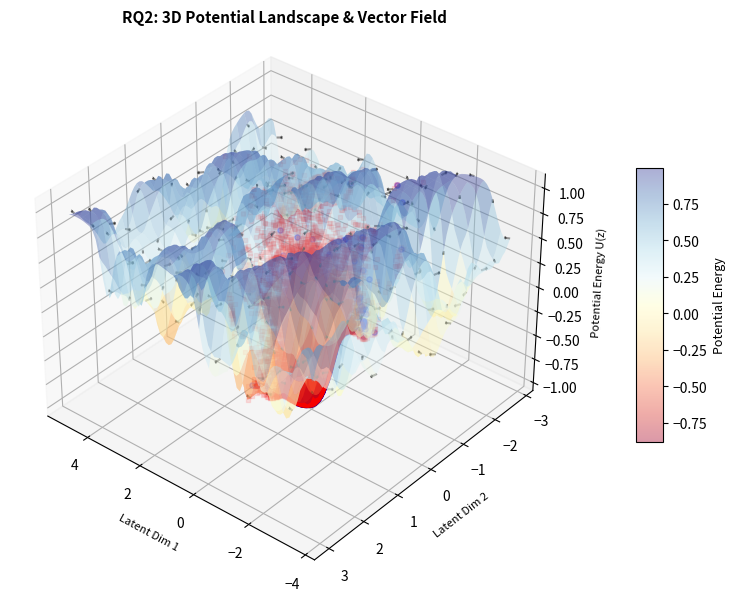

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import torch
from sklearn.decomposition import PCA

# ============================================================
# 1. Nature Style Configuration (3D + JP Fonts)
# ============================================================
def set_nature_style_3d():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 8,
        'axes.titlesize': 10,
        'legend.fontsize': 7,
        'savefig.dpi': 300,
        'figure.figsize': (6.0, 5.0), # 矢印が入るため少し余裕を持たせる
         'svg.fonttype': 'none', 
    })

# ============================================================
# 2. Main Visualization Function (3D Surface + Vector Field)
# ============================================================
def visualize_rq2_nature_3d_vectors(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style_3d()
    print("\n[Visualization] Generating RQ2 Landscape (3D + Vector Field)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # --- 1. データ点のエンコードとポテンシャル取得 ---
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        # 次元調整 (Padding)
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        # 各ノードの高さ(ポテンシャル)を取得
        potentials_nodes = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- 2. PCA Projection (2D座標系を作る) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- 3. Grid & Gradient Calculation (ベクトル場の計算) ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 80 # 計算用解像度
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # 勾配計算 (Autograd)
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    
    # 勾配をPCA空間(2D)へ射影
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    # ベクトル成分 (-勾配方向 = ポテンシャルが下がる方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # ================= Plotting 3D =================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. Surface Plot (地形)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', alpha=0.4, 
                           linewidth=0, antialiased=True, rstride=3, cstride=3)
    
    # B. Vector Field (Quiver) - 間引き処理
    # 全点描画すると真っ黒になるため、strideで間引く
    skip = 6 
    X_skip = X[::skip, ::skip]
    Y_skip = Y[::skip, ::skip]
    Z_skip = Z[::skip, ::skip]
    U_skip = U[::skip, ::skip]
    V_skip = V[::skip, ::skip]
    
    # 矢印の長さ調整 (正規化して一定の長さにすると見やすい場合と、強さを残す場合があります。ここでは強さを残しつつスケール調整)
    # Z方向成分(W)は0にして、等高線に沿った「水平方向の力」として描画するのが一般的で見やすいです
    ax.quiver(X_skip, Y_skip, Z_skip, U_skip, V_skip, np.zeros_like(Z_skip),
              length=0.15, normalize=True, color='black', alpha=0.4, arrow_length_ratio=0.3, label='Flow Field')

    # C. Scatter Plots (データ点)
    corp_x = z_2d[:num_corps, 0]
    corp_y = z_2d[:num_corps, 1]
    corp_z = potentials_nodes[:num_corps]
    
    patent_x = z_2d[num_corps:, 0]
    patent_y = z_2d[num_corps:, 1]
    patent_z = potentials_nodes[num_corps:]

    # 特許 (Patents) - 透明度 0.1
    ax.scatter(patent_x, patent_y, patent_z, 
               c='red', marker='s', s=5, 
               alpha=0.1, depthshade=False, # depthshade=Falseで色の濃さを距離に依存させない（透明度を厳密に適用）
               label='特許 (Patents)')

    # 企業 (Corporations) - 透明度 0.3
    ax.scatter(corp_x, corp_y, corp_z, 
               c='blue', marker='o', s=15, 
               alpha=0.3, depthshade=False,
               label='企業 (Corporations)')

    # D. Labels & View
    ax.set_title("RQ2: 3D Potential Landscape & Vector Field", fontsize=11, fontweight='bold')
    ax.set_xlabel("Latent Dim 1", fontsize=8)
    ax.set_ylabel("Latent Dim 2", fontsize=8)
    ax.set_zlabel("Potential Energy U(z)", fontsize=8)
    
    # 視点の初期設定 (見やすい角度)
    ax.view_init(elev=35, azim=130)

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label('Potential Energy', fontsize=9)

    plt.tight_layout()
    
    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（プレビュー・確認用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.png',
        dpi=300
    )
    print(f"Visualization saved to ./outputs/")
    plt.show()

if __name__ == "__main__":
    visualize_rq2_nature_3d_vectors(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] Verifying Attractor Validity (English Labels)...
Evaluation plot saved to ./outputs/
Correlation: -0.6818


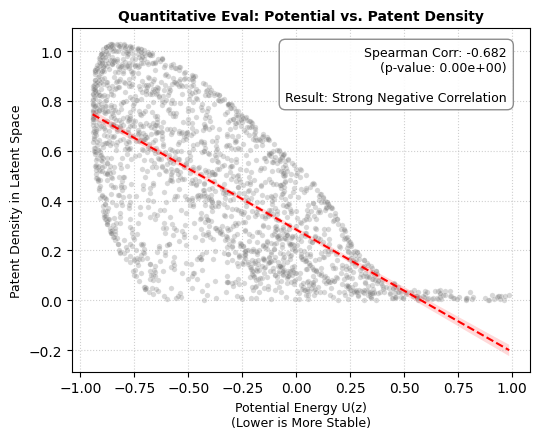

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_rq2_quantitative_english(model, config, num_corps, device, year_idx=-1):
    # スタイル設定（英語フォントのみ使用）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 標準的な英語フォント
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',   # SVGで文字をアウトライン化しない
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (English Labels)...")
    
    # 1. データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 2. 特許ノード抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 3. 密度推定
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except:
        return

    # 4. 相関計算
    corr, p_value = spearmanr(patent_potentials, densities)
    
    # 5. プロット（英語ラベル）
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    if len(patent_potentials) > 2000:
        idx = np.random.choice(len(patent_potentials), 2000, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = patent_potentials
        plot_y = densities
        alpha_val = 0.5
        
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', edgecolors='white', linewidth=0.3, label='Patents')
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # 英語タイトル・ラベル
    ax.set_title("Quantitative Eval: Potential vs. Patent Density", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Patent Density in Latent Space", fontsize=9)
    
    # 統計量テキスト
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n\n"
                  f"Result: Strong Negative Correlation")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（確認・レビュー用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.png',
        dpi=300
    )

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_quantitative_english(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] 技術戦略マップ（日本語版）を作成中...
  Spearman Correlation: -0.6818
日本語版プロットを保存しました:
 - ./outputs/nature_strategy_landscape_jp.svg
 - ./outputs/nature_strategy_landscape_jp.png


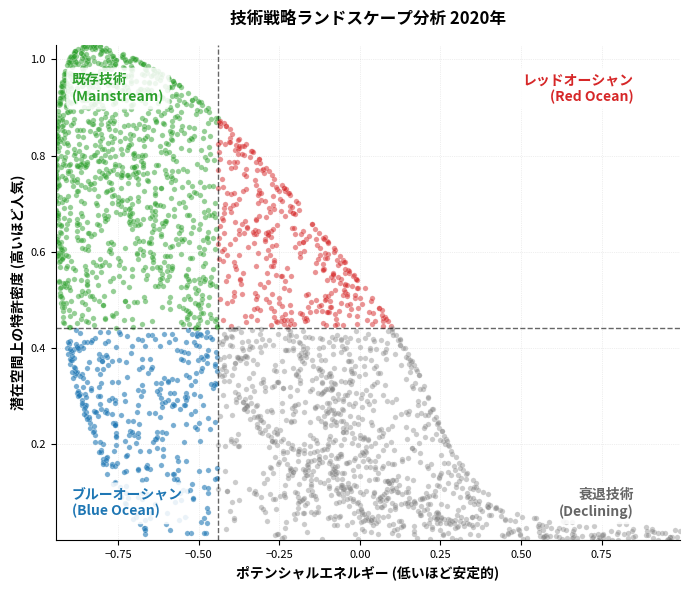

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        # 日本語フォントの優先順位設定
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (日本語版)
# ============================================================
def evaluate_strategic_quadrants_jp(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（日本語版）を作成中...")
    
    # --- 1. データ準備と計算 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード & ポテンシャル計算
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許データのみ抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 密度推定 (KDE)
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # --- 2. サンプリング (描画負荷軽減) ---
    N_PLOT = 3000
    if len(patent_potentials) > N_PLOT:
        idx = np.random.choice(len(patent_potentials), N_PLOT, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = patent_potentials
        plot_y = densities

    # --- 3. 統計的評価 (Spearman相関) ---
    corr, p_value = spearmanr(patent_potentials, densities)
    print(f"  Spearman Correlation: {corr:.4f}")

    # --- 4. 4象限の分類ロジック ---
    # 中央値をしきい値とする
    x_thr = np.median(plot_x) # ポテンシャルしきい値
    y_thr = np.median(plot_y) # 密度しきい値
    
    # 1. ブルーオーシャン (左下: 安定 & 低密度) -> 最有望
    # ポテンシャルが低い(安定) かつ 密度が低い(空いている)
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 2. 既存技術 (左上: 安定 & 高密度) -> 成熟・必須
    # ポテンシャルが低い(安定) かつ 密度が高い(混んでいる)
    mask_main = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 3. レッドオーシャン (右上: 不安定 & 高密度) -> 過熱・激戦
    # ポテンシャルが高い(不安定) かつ 密度が高い(混んでいる)
    mask_red = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 4. 衰退技術 (右下: 不安定 & 低密度) -> リスク・探索
    # ポテンシャルが高い(不安定) かつ 密度が低い(空いている)
    mask_decline = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 5. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 各象限の散布図描画
    # 既存技術 (緑)
    ax.scatter(plot_x[mask_main], plot_y[mask_main], c='#2ca02c', s=15, alpha=0.5, 
               label='既存技術 (安定・成熟)', edgecolors='white', linewidth=0.2)
    # ブルーオーシャン (青)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=15, alpha=0.6, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.2)
    # レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (激戦)', edgecolors='white', linewidth=0.2)
    # 衰退技術 (灰)
    ax.scatter(plot_x[mask_decline], plot_y[mask_decline], c='#7f7f7f', s=15, alpha=0.4, 
               label='衰退技術 (不安定)', edgecolors='white', linewidth=0.2)

    # しきい値の線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # 象限ラベル (背景ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='none')
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上: 既存技術
    ax.text(x_min + (x_thr - x_min)*0.1, y_max - (y_max - y_thr)*0.1, 
            "既存技術\n(Mainstream)", 
            fontsize=10, color='#2ca02c', fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下: ブルーオーシャン
    ax.text(x_min + (x_thr - x_min)*0.1, y_min + (y_thr - y_min)*0.1, 
            "ブルーオーシャン\n(Blue Ocean)", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上: レッドオーシャン
    ax.text(x_max - (x_max - x_thr)*0.1, y_max - (y_max - y_thr)*0.1, 
            "レッドオーシャン\n(Red Ocean)", 
            fontsize=10, color='#d62728', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下: 衰退技術
    ax.text(x_max - (x_max - x_thr)*0.1, y_min + (y_thr - y_min)*0.1, 
            "衰退技術\n(Declining)", 
            fontsize=10, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の特許密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"技術戦略ランドスケープ分析 {target_year}年", fontsize=12, fontweight='bold', pad=15)
    
    # 軸範囲
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # グリッド
    ax.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.svg',
        format='svg',
        bbox_inches='tight'
    )
    
    # PNG（確認・スライド用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.png',
        dpi=300
    )
    
    print("日本語版プロットを保存しました:")
    print(" - ./outputs/nature_strategy_landscape_jp.svg")
    print(" - ./outputs/nature_strategy_landscape_jp.png")
    plt.show()


# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        evaluate_strategic_quadrants_jp(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )
    else:
        print("Model or config not loaded.")

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_quadrant_patents(model, config, df, num_corps, device, year_idx=-1):
    print(f"\n[Analysis] 各象限の具体的な特許を抽出しています...")
    
    # --- 1. 計算処理（先ほどと同様） ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャル計算
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許部分の抽出
    patent_indices = np.arange(num_corps, len(z_np)) # ノード全体のインデックス
    patent_z = z_np[patent_indices]
    patent_pots = potentials[patent_indices]
    
    # 密度計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        patent_densities = kde(z_2d.T)
    except:
        print("密度計算に失敗しました。")
        return pd.DataFrame()

    # --- 2. 象限判定 ---
    x_thr = np.median(patent_pots)    # ポテンシャルの中央値
    y_thr = np.median(patent_densities) # 密度の中央値
    
    # マスク作成
    mask_blue = (patent_pots <= x_thr) & (patent_densities <= y_thr)
    mask_main = (patent_pots <= x_thr) & (patent_densities > y_thr)
    mask_red  = (patent_pots > x_thr) & (patent_densities > y_thr)
    mask_decline = (patent_pots > x_thr) & (patent_densities <= y_thr)
    
    # --- 3. 特許情報取得用のヘルパー関数 ---
    # df上のインデックスと対応付けるための特許IDリスト
    patent_id_list = config.get('patents', df['patent_number'].tolist())
    
    def get_top_k_patents(mask, category_name, sort_by='potential', ascending=True, k=5):
        # マスクに該当する特許のインデックス（0始まりの相対インデックス）を取得
        relative_indices = np.where(mask)[0]
        
        if len(relative_indices) == 0:
            return []
            
        # ソート基準
        if sort_by == 'potential':
            scores = patent_pots[relative_indices]
        else: # density
            scores = patent_densities[relative_indices]
            
        # ソート実行
        if ascending:
            sorted_order = np.argsort(scores) # 小さい順 (Best Potential)
        else:
            sorted_order = np.argsort(scores)[::-1] # 大きい順 (High Density)
            
        top_indices = relative_indices[sorted_order][:k]
        
        results = []
        for idx in top_indices:
            # 元の特許リストからIDを取得
            # patent_indices[idx] はグラフ全体のノードID
            # idx は patent_indices 内の相対位置 -> これが patent_id_list のインデックスに対応
            if idx < len(patent_id_list):
                pid = patent_id_list[idx]
                
                # データフレームから情報を引く
                row = df[df['patent_number'] == pid]
                if not row.empty:
                    title = row.iloc[0]['patent_name'] if 'patent_name' in row.columns else row.iloc[0].get('title', 'No Title')
                    # テキスト/要約があれば取得 (カラム名はデータに合わせて調整してください)
                    abstract = row.iloc[0]['abstract'] if 'abstract' in row.columns else ""
                    if pd.isna(abstract) or abstract == "":
                        abstract = row.iloc[0]['text'][:50] + "..." if 'text' in row.columns else ""
                        
                    results.append({
                        "象限": category_name,
                        "特許番号": pid,
                        "発明の名称": title,
                        "要約(抜粋)": str(abstract)[:100], # 長すぎる場合はカット
                        "ポテンシャル": f"{patent_pots[idx]:.4f}",
                        "密度スコア": f"{patent_densities[idx]:.4f}"
                    })
        return results

    # --- 4. 各象限から抽出 ---
    rows = []
    # ブルーオーシャン: ポテンシャルが低い順（＝最も確実な穴場）
    rows.extend(get_top_k_patents(mask_blue, "ブルーオーシャン (有望)", sort_by='potential', ascending=True))
    
    # 既存技術: 密度が高い順（＝最も基本的な技術）
    rows.extend(get_top_k_patents(mask_main, "既存技術 (成熟)", sort_by='density', ascending=False))
    
    # レッドオーシャン: 密度が高い順（＝最も激戦区）
    rows.extend(get_top_k_patents(mask_red, "レッドオーシャン (激戦)", sort_by='density', ascending=False))
    
    # 衰退/フロンティア: ポテンシャルが高い順（＝最もリスクが高い/先端的すぎる）
    rows.extend(get_top_k_patents(mask_decline, "衰退/フロンティア (高リスク)", sort_by='potential', ascending=False))

    return pd.DataFrame(rows)

# ============================================================
# 実行
# ============================================================
if __name__ == "__main__":
    # データフレーム df に 'patent_number', 'patent_name' (または 'title') があることを確認してください
    
    df_results = extract_quadrant_patents(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )
    
    # 表示設定（省略されずに表示）
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 50)
    pd.set_option('display.width', 1000)
    
    print("\n【象限別・代表特許リスト】")
    # Jupyterでない場合は print(df_results)
    try:
        from IPython.display import display
        display(df_results)
    except:
        print(df_results)


[Analysis] 各象限の具体的な特許を抽出しています...

【象限別・代表特許リスト】


,象限,特許番号,発明の名称,要約(抜粋),ポテンシャル,密度スコア
0,ブルーオーシャン (有望),特開2019-120099,鋼管矢板の継手構造,,-0.9147,0.4298
1,ブルーオーシャン (有望),特開2017-019418,運搬装置,,-0.9144,0.4328
2,ブルーオーシャン (有望),特開2019-078101,開口の補強構造,,-0.9136,0.4239
3,ブルーオーシャン (有望),特開2016-038043,滑り免震機構,,-0.9130,0.4198
4,ブルーオーシャン (有望),特開2017-193458,水硬性組成物の製造方法,,-0.9125,0.4159
5,既存技術 (成熟),特開2012-231551,負荷機器と電源機器,,-0.8258,1.0303
6,既存技術 (成熟),特開2015-151808,地盤改良用伸縮装置及び地盤改良装置,,-0.8242,1.0300
7,既存技術 (成熟),特開2018-150754,プレキャストコンクリート版の接合構造及びプレキャストコンクリート版の施工方法,,-0.8393,1.0300
8,既存技術 (成熟),特開2017-048612,アーチ橋の架設方法,,-0.8246,1.0299
9,既存技術 (成熟),特開2018-071097,薬液注入工法,,-0.8199,1.0298


In [13]:
import pandas as pd
import numpy as np
import os
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def save_quadrant_patents_to_csv(model, config, df, num_corps, device, output_dir="quadrant_data", year_idx=-1):
    """
    各象限の特許を抽出し、個別のCSVファイルに保存する関数
    """
    print(f"\n[Analysis] 象限分析とファイル保存を開始します...")
    
    # 保存先ディレクトリの作成
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"  フォルダ作成: {output_dir}")

    # --- 1. 計算処理 (ポテンシャルと密度の計算) ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # モデル構造に合わせてポテンシャルネットを取得
    if hasattr(model, 'temporal_predictor'): 
        pot_net = model.temporal_predictor.potential_net
    else: 
        pot_net = model.potential_net

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        # 次元調整（必要な場合）
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
            
        # エンコードして潜在変数zを取得
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許部分のみ抽出
    patent_indices = np.arange(num_corps, len(z_np)) # ノード全体のインデックス
    patent_z = z_np[patent_indices]
    patent_pots = potentials[patent_indices]
    
    # 密度計算 (KDE)
    print("  密度推定を実行中...")
    pca = PCA(n_components=2)
    # PCAで2次元に落としてから密度計算（高次元だとKDEが不安定になるため）
    z_2d = pca.fit_transform(patent_z) if patent_z.shape[1] > 2 else patent_z
    try:
        kde = gaussian_kde(z_2d.T)
        patent_densities = kde(z_2d.T)
    except Exception as e:
        print(f"エラー: 密度計算に失敗しました。({e})")
        return

    # --- 2. 象限判定 (中央値で分割) ---
    x_thr = np.median(patent_pots)      # ポテンシャルの中央値
    y_thr = np.median(patent_densities) # 密度の中央値
    
    print(f"  閾値設定 -> ポテンシャル: {x_thr:.4f}, 密度: {y_thr:.4f}")

    # 4つの象限マスクを作成
    masks = {
        "1_blue_ocean": (patent_pots <= x_thr) & (patent_densities <= y_thr),  # 低ポテンシャル・低密度
        "2_mainstream": (patent_pots <= x_thr) & (patent_densities > y_thr),   # 低ポテンシャル・高密度
        "3_red_ocean":  (patent_pots > x_thr)  & (patent_densities > y_thr),   # 高ポテンシャル・高密度
        "4_frontier":   (patent_pots > x_thr)  & (patent_densities <= y_thr)   # 高ポテンシャル・低密度
    }
    
    # CSVファイル名のマッピング
    file_names = {
        "1_blue_ocean": "blue_ocean_patents.csv",   # 有望・穴場
        "2_mainstream": "mainstream_patents.csv",   # 既存・成熟
        "3_red_ocean":  "red_ocean_patents.csv",    # 激戦・過密
        "4_frontier":   "frontier_patents.csv"      # 萌芽・衰退
    }

    # --- 3. データ抽出と保存 ---
    # patent_id_list: グラフのノード順序と対応する特許番号リスト
    patent_id_list = config.get('patents', df['patent_number'].tolist())
    
    # データフレーム検索の高速化のためにインデックスを設定
    df_indexed = df.set_index('patent_number') if 'patent_number' in df.columns else df

    summary_counts = {}

    for key, mask in masks.items():
        # マスクに該当する特許の相対インデックスを取得
        relative_indices = np.where(mask)[0]
        count = len(relative_indices)
        summary_counts[key] = count
        
        if count == 0:
            print(f"  [Skip] {key} は該当データがありません。")
            continue

        # 該当データの情報を収集
        rows = []
        for idx in relative_indices:
            # 配列インデックスオーバーフロー防止
            if idx >= len(patent_id_list): continue
                
            pid = patent_id_list[idx]
            
            # データフレームから詳細情報を取得
            try:
                # locを使って高速アクセス
                if pid in df_indexed.index:
                    # 重複IDがある場合は最初の1行を取得
                    item = df_indexed.loc[pid]
                    if isinstance(item, pd.DataFrame):
                        item = item.iloc[0]
                    
                    title = item.get('patent_name', item.get('title', 'No Title'))
                    abstract = item.get('description', item.get('text', ''))
                    
                    rows.append({
                        "patent_number": pid,
                        "title": title,
                        "potential_score": patent_pots[idx],
                        "density_score": patent_densities[idx],
                        "abstract": abstract  # 全文が必要ならここで取得
                    })
            except Exception as e:
                continue

        # DataFrame化して保存
        if rows:
            save_df = pd.DataFrame(rows)
            # スコア順にソート（ブルーオーシャンならポテンシャルが低い順、など）
            if "blue" in key or "mainstream" in key:
                save_df = save_df.sort_values(by="potential_score", ascending=True)
            else:
                save_df = save_df.sort_values(by="density_score", ascending=False)
                
            save_path = os.path.join(output_dir, file_names[key])
            save_df.to_csv(save_path, index=False, encoding='utf-8-sig') # Excelで文字化けしないようsig付き
            print(f"  ✓ 保存完了: {save_path} ({len(save_df)}件)")

    print("\n[Summary] 保存された件数:")
    for k, v in summary_counts.items():
        print(f"  - {k}: {v} 件")

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    # 実行
    save_quadrant_patents_to_csv(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device,
        output_dir="quadrant_analysis_results" # 保存先フォルダ名
    )


[Analysis] 象限分析とファイル保存を開始します...
  密度推定を実行中...
  閾値設定 -> ポテンシャル: -0.4112, 密度: 0.4358
  ✓ 保存完了: quadrant_analysis_results/blue_ocean_patents.csv (2378件)
  ✓ 保存完了: quadrant_analysis_results/mainstream_patents.csv (7314件)
  ✓ 保存完了: quadrant_analysis_results/red_ocean_patents.csv (2378件)
  ✓ 保存完了: quadrant_analysis_results/frontier_patents.csv (7314件)

[Summary] 保存された件数:
  - 1_blue_ocean: 2378 件
  - 2_mainstream: 7314 件
  - 3_red_ocean: 2378 件
  - 4_frontier: 7314 件



[Evaluation] 戦略的ランドスケープマップを作成中...
マップを保存しました: ./outputs/strategic_landscape_map.png


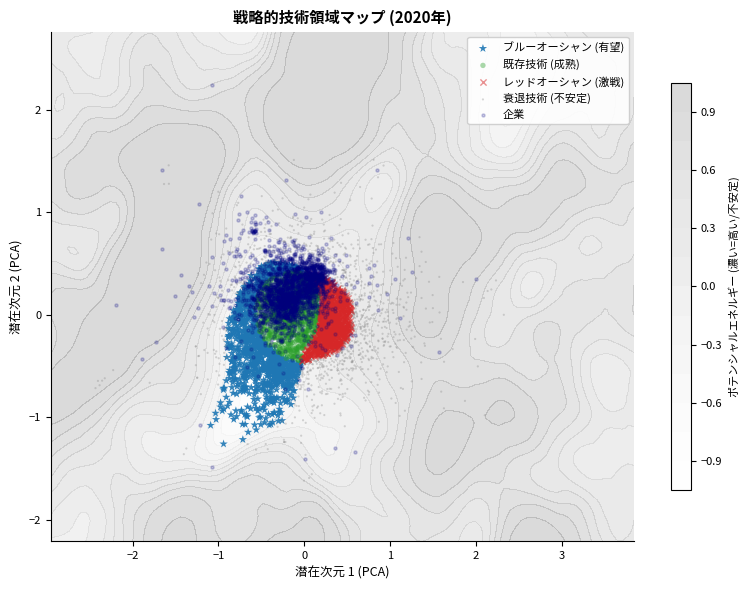

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (7.2, 5.0), # ダブルカラム幅に近い
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 統合可視化関数: 戦略的ランドスケープマップ
# ============================================================
def visualize_strategic_landscape_map(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 戦略的ランドスケープマップを作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # ポテンシャル値（全データ）
        potentials_all = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 特許データに基づく4象限分類 ---
    # 特許のみ抽出
    patent_indices = np.arange(num_corps, len(z_np))
    patent_z = z_np[patent_indices]
    patent_potentials = potentials_all[patent_indices]
    
    # PCA (2次元投影)
    pca = PCA(n_components=2)
    z_all_2d = pca.fit_transform(z_np) # 全体でPCA
    patent_z_2d = z_all_2d[patent_indices] # 特許部分のみ
    
    # 密度推定 (KDE)
    try:
        kde = gaussian_kde(patent_z_2d.T)
        patent_densities = kde(patent_z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # しきい値決定 (中央値)
    pot_thr = np.median(patent_potentials)
    den_thr = np.median(patent_densities)
    
    # 特許ごとの象限ラベル付け
    # 0: ブルーオーシャン (Pot:Low, Den:Low)
    # 1: 既存技術 (Pot:Low, Den:High)
    # 2: レッドオーシャン (Pot:High, Den:High)
    # 3: 衰退技術 (Pot:High, Den:Low)
    patent_labels = np.zeros(len(patent_indices), dtype=int)
    
    mask_blue = (patent_potentials <= pot_thr) & (patent_densities <= den_thr)
    mask_main = (patent_potentials <= pot_thr) & (patent_densities > den_thr)
    mask_red = (patent_potentials > pot_thr) & (patent_densities > den_thr)
    mask_decline = (patent_potentials > pot_thr) & (patent_densities <= den_thr)
    
    patent_labels[mask_blue] = 0
    patent_labels[mask_main] = 1
    patent_labels[mask_red] = 2
    patent_labels[mask_decline] = 3

    # --- 3. 背景のポテンシャル地形計算 ---
    x_min, x_max = z_all_2d[:, 0].min(), z_all_2d[:, 0].max()
    y_min, y_max = z_all_2d[:, 1].min(), z_all_2d[:, 1].max()
    margin = 0.5
    
    grid_res = 100
    grid_x = np.linspace(x_min - margin, x_max + margin, grid_res)
    grid_y = np.linspace(y_min - margin, y_max + margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        Z_pot = pot_net(grid_tensor).squeeze().cpu().numpy().reshape(X.shape)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 背景: ポテンシャル等高線 (薄く)
    contour = ax.contourf(X, Y, Z_pot, levels=15, cmap='Greys', alpha=0.15)
    
    # 色設定 (4象限分類と合わせる)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    labels = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退技術 (不安定)']
    markers = ['*', 'o', 'x', '.']
    sizes = [40, 15, 20, 10]
    alphas = [0.9, 0.4, 0.5, 0.3]
    
    # 象限ごとに特許をプロット
    for i in range(4):
        mask = (patent_labels == i)
        # データが多すぎる場合はサンプリング
        if np.sum(mask) > 1000:
            indices = np.where(mask)[0]
            sampled_indices = np.random.choice(indices, 1000, replace=False)
            p_z = patent_z_2d[sampled_indices]
        else:
            p_z = patent_z_2d[mask]
            
        ax.scatter(p_z[:, 0], p_z[:, 1], c=colors[i], label=labels[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], edgecolors='none')

    # 企業 (青い点, 透明度高め)
    corp_z_2d = z_all_2d[:num_corps]
    ax.scatter(corp_z_2d[:, 0], corp_z_2d[:, 1], c='navy', s=5, alpha=0.2, label='企業', zorder=1)

    # 凡例と装飾
    ax.legend(loc='upper right', frameon=True, framealpha=0.9)
    ax.set_title(f"戦略的技術領域マップ ({target_year}年)", fontweight='bold')
    ax.set_xlabel("潜在次元 1 (PCA)")
    ax.set_ylabel("潜在次元 2 (PCA)")
    
    # カラーバー (ポテンシャルの高低を示す)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('ポテンシャルエネルギー (濃い=高い/不安定)', fontsize=8)

    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_map.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_map.png', dpi=300)
    print("マップを保存しました: ./outputs/strategic_landscape_map.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_map(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )

Loading data from ../dataset/topic_info3.csv...
Training Standard GODE...
Epoch 1/15 | Loss: 23.5525
Epoch 2/15 | Loss: 11.4278
Epoch 3/15 | Loss: 8.7772
Epoch 4/15 | Loss: 7.2759
Epoch 5/15 | Loss: 7.2415
Epoch 6/15 | Loss: 7.0361
Epoch 7/15 | Loss: 6.9904
Epoch 8/15 | Loss: 6.9772
Epoch 9/15 | Loss: 6.9264
Epoch 10/15 | Loss: 6.9283
Epoch 11/15 | Loss: 6.8997
Epoch 12/15 | Loss: 6.9468
Epoch 13/15 | Loss: 6.9271
Epoch 14/15 | Loss: 6.9376
Epoch 15/15 | Loss: 6.9232

Visualizing Year: 2020

Generating Vector Field for Standard GODE (SVG Output)...
Visualization saved to ./standard_ode_vector_field_2020.svg


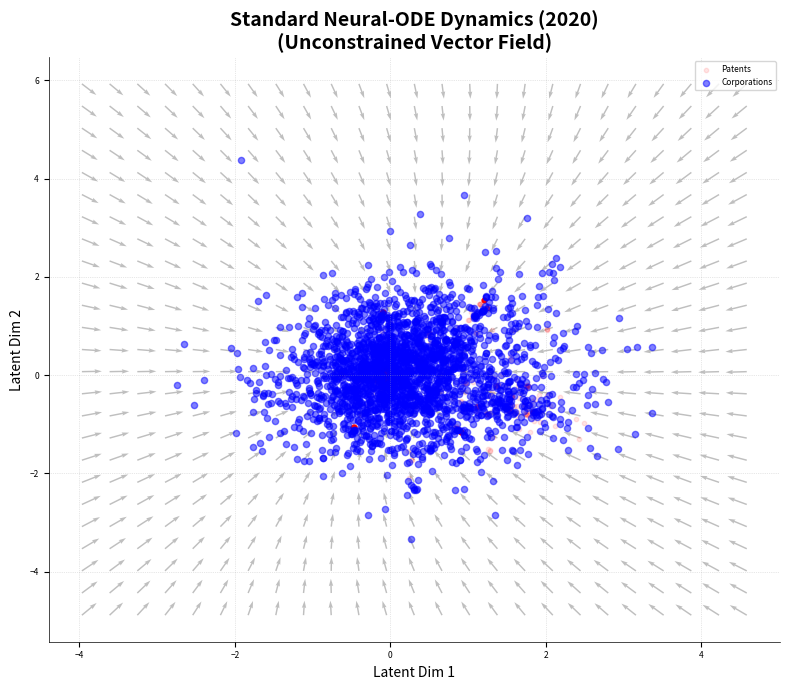

In [24]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
import os

# ============================================================
# 基本設定
# ============================================================
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except: return None
    return None

def preprocess_and_build_graphs(file_path):
    print(f"Loading data from {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None, None, None, None

    combined_vectors = []
    valid_indices = []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
    
    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else x
        except: return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]

    # グラフ構築
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    for year, group in df.groupby(df['year_month'].dt.year):
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx])
                    edges.append([p_idx, c_idx])
        
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, num_nodes=total_nodes)

    return global_graph_dict, len(all_corporations), total_nodes, input_dim

# ============================================================
# 2. モデル定義 (Standard GODE & Encoder)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return z, mu, logvar

    def predict_future(self, z_curr):
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4')[-1]
        return z_next

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

# ============================================================
# 3. 学習関数 (Standard GODE専用)
# ============================================================
def train_standard_ode(model, graphs, num_epochs=15):
    print("Training Standard GODE...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    years = sorted(graphs.keys())
    train_years = years[:-1]

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for i in range(len(train_years) - 1):
            y_t = train_years[i]
            y_next = train_years[i+1]
            data_t = graphs[y_t].to(device)
            data_next = graphs[y_next].to(device)

            optimizer.zero_grad()
            
            # Encode & Recon
            z_t, _, _ = model.encode(data_t.x, data_t.edge_index)
            pos_pred = model.decode(z_t, data_t.edge_index)
            neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
            neg_pred = model.decode(z_t, neg_idx)
            recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
            
            # Future Prediction (MSE)
            # Standard ODEは「何でもあり」の動きをするため、この項で無理やり合わせようとする
            z_pred = model.predict_future(z_t)
            with torch.no_grad():
                _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
            
            # MSE Loss
            loss_pred = F.mse_loss(z_pred, mu_next)
            
            total_loss = recon_loss + loss_pred
            total_loss.backward()
            optimizer.step()
            epoch_loss += total_loss.item()
            
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}")
    
    return model

# ============================================================
# 4. 可視化関数 (ベクトル場 - SVG保存)
# ============================================================
def visualize_standard_ode_2d(model, data, num_corps, device):
    print("\nGenerating Vector Field for Standard GODE (SVG Output)...")
    model.eval()
    data = data.to(device)
    
    # 1. Encode
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCA
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. Grid
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 25
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. Vector Field (dz/dt)
    with torch.no_grad():
        dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
    
    dz_dt_2d = np.dot(dz_dt.cpu().numpy(), pca.components_.T)
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Quiver (ベクトル場)
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, angles='xy', scale_units='xy', width=0.002)
    
    # Scatter (データ点)
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.1, s=10, label='Patents')
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.5, s=20, label='Corporations')

    ax.set_title("Standard Neural-ODE Dynamics (2020)\n(Unconstrained Vector Field)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Latent Dim 1', fontsize=10)
    ax.set_ylabel('Latent Dim 2', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # === SVGで保存 ===
    save_path = './standard_ode_vector_field_2020.svg' # ファイル名に2020を追加
    plt.tight_layout()
    plt.savefig(save_path, format='svg', bbox_inches='tight')
    print(f"Visualization saved to {save_path}")
    plt.show()

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # データパスを指定してください
    DATA_PATH = '../dataset/topic_info3.csv' 
    
    if os.path.exists(DATA_PATH):
        # 1. Load Data
        graphs, num_corps, total_n, in_dim = preprocess_and_build_graphs(DATA_PATH)
        
        if graphs:
            # 2. Initialize Model
            model = StandardGODE(total_n, num_corps, in_dim, hidden_dim=64, latent_dim=16).to(device)
            
            # 3. Train
            model = train_standard_ode(model, graphs, num_epochs=15)
            
            # 4. Visualize (Target Year: 2020)
            target_year = 2020
            
            if target_year in graphs:
                print(f"\nVisualizing Year: {target_year}")
                visualize_standard_ode_2d(model, graphs[target_year], num_corps, device)
            else:
                print(f"\nWarning: Year {target_year} not found in data. Available years: {list(graphs.keys())}")
                # データがない場合は最後の年を表示
                last_year = max(graphs.keys())
                print(f"Fallback to visualization for year: {last_year}")
                visualize_standard_ode_2d(model, graphs[last_year], num_corps, device)
    else:
        print(f"File not found: {DATA_PATH}. Please check the path.")